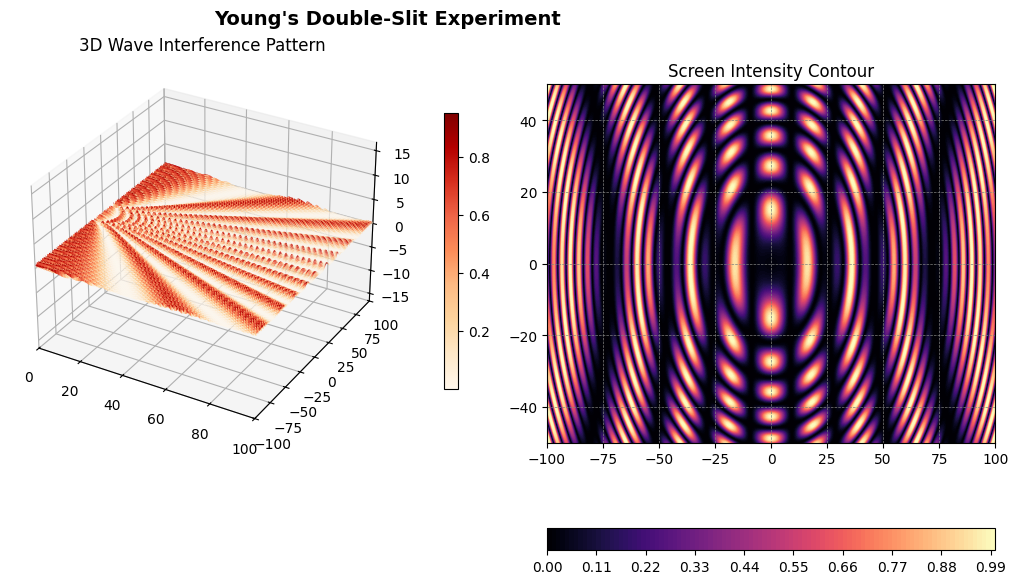

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib import colors
from mpl_toolkits.mplot3d import axes3d



#Data input from user:




S=float(input("whats the screen pos? :"))
t=float(input("t at which to present the snapshot? :"))

#Initialize:

x=np.linspace(0,S,300)
y=np.linspace(-100, 100, 3000)
z=np.linspace(-50, 50, 3000)


X,Y=np.meshgrid(x,y)

Γ,ζ=np.meshgrid(y,z)

#Constants :

λ=5 # 7e-7 m
c=3 # 3e8 m/s
A=5 

k=2*np.pi/λ
ω=c*k

d=30 #10e-4


#Sources  (At the level of μm ):

s1=(0,d/2,0)
s2=(0,-d/2,0)

# Defining the light waves:

def o1(x,y,z,t):

    r1 = np.sqrt((x-s1[0])**2 + (y-s1[1])**2 +(z-s1[2])**2 )
    a=A*np.sin(ω*t-k*r1)
    return a

def o2(x,y,z,t):

    r2 = np.sqrt((x-s2[0])**2 + (y-s2[1])**2 + (z-s2[2])**2)
    a= A*np.sin(ω*t-k*r2)
    return a

def get_wave():
    wave = np.where(X<=S,((o1(X,Y,1,t) + o2(X,Y,1,t))**2),0)
    return wave

#Intensity (instantanous) calculation:

def get_int_screen(t):
    I=(o1(S,Γ,ζ,t)+o2(S,Γ,ζ,t))**2
    
    I0=(o1(S,y,0,t)+o2(S,y,0,t))**2
    
    return I , I0




#Plotting:


Z = get_wave()/np.max(get_wave())

fig = plt.figure(figsize=(12.5, 5.8), constrained_layout=True)
fig.suptitle("Young's Double-Slit Experiment", fontsize=14, fontweight="bold")
gs = fig.add_gridspec(1, 2, width_ratios=[1.4, 1])

ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax1.set_title("3D Wave Interference Pattern")
box = ax1.plot_surface(X, Y, Z, cmap="OrRd", linewidth=0, antialiased=True, rcount=220, ccount=220)
fig.colorbar(box, ax=ax1, shrink=0.72, pad=0.08)
ax1.set_xlim3d(0,S)
ax1.set_ylim3d(min(y), max(y))
ax1.set_zlim3d(min(z)/3,max(z)/3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Screen Intensity Contour")
ax2.set_box_aspect(0.8)
ax2.set_xlim(min(y), max(y))
ax2.set_ylim(min(z),max(z))
cont2 = ax2.contourf(Γ,ζ,get_int_screen(t)[0]/np.max(get_int_screen(t)[0]),levels=100,cmap="magma")
ax2.grid(True,color="gray",linestyle="--",linewidth=0.5)
fig.colorbar(cont2, ax=ax2, orientation="horizontal", pad=0.14, fraction=0.08)

plt.show()

# Time avg intensity

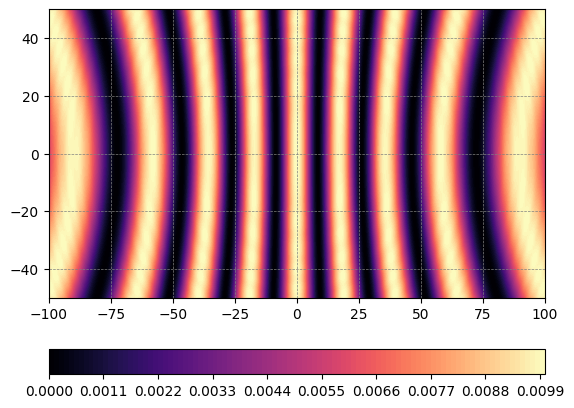

In [3]:

t1=np.linspace(0,10,100)

I=np.zeros_like(get_int_screen(0)[0])
I0=np.zeros_like(get_int_screen(0)[1])

for n in t1:

 I+=get_int_screen(n)[0]
 I0+=get_int_screen(n)[1]
 
I=I/np.max(I)
I0=I0/np.max(I0)

plt.contourf(Γ,ζ,I/len(t1),levels=100,cmap="magma")
plt.grid(True,color="gray",linestyle="--",linewidth=0.5)

plt.colorbar(orientation="horizontal", pad=0.14, fraction=0.08)


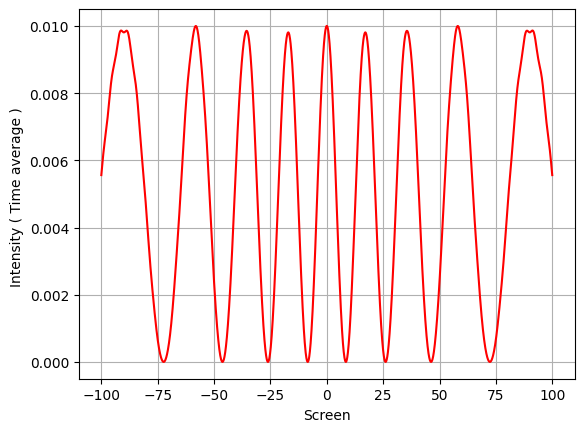

In [ ]:
plt.plot(y,I0/len(t1),color="red")
plt.xlabel("Screen")
plt.ylabel("Intensity ( Time average ) ")
plt.grid(True)